# PHYS310 Final Prject Code
Data driven prediction of material properties with machine learning - Predicting the Band Gaps of Inorganic Solids.

Goals are to classify whether inorganic solids are metal or nonmetal and to predict the band gaps of them.

In [1]:
import pandas as pd
import numpy as np
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold


c:\Users\Jinseok Bae\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### First Step - load the data from the paper
The dataset was obtained from the paper given (Complete training set of experimental band gaps and DFT calculated zero band gaps)
- **Note: if you have the featurized dataset you can skip to third step**

In [2]:
df = pd.read_excel('jz8b00124_si_002.xlsx')

- noticed that there were some composition with ',' in. And since it can't go through the next step I removed them.

In [3]:
df = df[~df["composition"].str.contains(",")]

### Second Step - Material Informatics
Convert our composition data into numberical features. (Featurize the composition-based data)
- use Magpie

In [4]:
df['composition'] = df['composition'].apply(Composition)
print(df)
df.to_excel("df.xlsx", index=False)


       composition  Eg (eV)
0     (Hg, Cd, Te)    0.350
1         (Cu, Br)    3.077
2          (Lu, P)    1.300
3     (Cu, Sb, Se)    0.400
4          (Zn, O)    3.436
...            ...      ...
6348   (Sc, Co, O)    0.000
6349  (Tm, Mg, Tl)    0.000
6350      (Nb, Ga)    0.000
6351      (Tb, Sb)    0.000
6352  (Lu, Al, Tc)    0.000

[6031 rows x 2 columns]


In [5]:
featurizer = ElementProperty.from_preset('magpie')

df_feat = featurizer.featurize_dataframe(df, col_id="composition", ignore_errors=True)

print(df_feat.head())


ElementProperty: 100%|██████████| 6031/6031 [03:53<00:00, 25.83it/s]


    composition  Eg (eV)  MagpieData minimum Number  \
0  (Hg, Cd, Te)    0.350                       48.0   
1      (Cu, Br)    3.077                       29.0   
2       (Lu, P)    1.300                       15.0   
3  (Cu, Sb, Se)    0.400                       29.0   
4       (Zn, O)    3.436                        8.0   

   MagpieData maximum Number  MagpieData range Number  MagpieData mean Number  \
0                       80.0                     32.0                   61.20   
1                       35.0                      6.0                   32.00   
2                       71.0                     56.0                   43.00   
3                       51.0                     22.0                   34.25   
4                       30.0                     22.0                   19.00   

   MagpieData avg_dev Number  MagpieData mode Number  \
0                    13.1600                    52.0   
1                     3.0000                    29.0   
2             

In [6]:
print(list(df_feat.columns))

['composition', 'Eg (eV)', 'MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number', 'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber', 'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber', 'MagpieData avg_dev MendeleevNumber', 'MagpieData mode MendeleevNumber', 'MagpieData minimum AtomicWeight', 'MagpieData maximum AtomicWeight', 'MagpieData range AtomicWeight', 'MagpieData mean AtomicWeight', 'MagpieData avg_dev AtomicWeight', 'MagpieData mode AtomicWeight', 'MagpieData minimum MeltingT', 'MagpieData maximum MeltingT', 'MagpieData range MeltingT', 'MagpieData mean MeltingT', 'MagpieData avg_dev MeltingT', 'MagpieData mode MeltingT', 'MagpieData minimum Column', 'MagpieData maximum Column', 'MagpieData range Column', 'MagpieData mean Column', 'MagpieData avg_dev Column', 'MagpieData mode Column', 'MagpieData minimum Row', 'MagpieData max

In [7]:
# saving the featurized data into excel file so that I dont have to run this code everytime I need it.
df_feat.to_excel("features_.xlsx", index=False)

### Third Step - load the featurized data

In [8]:
df = pd.read_excel('features_.xlsx')

In [9]:
df = df.fillna(0)

### Forth Step - SVC Classifier
use SVC classifier to classify whether it is metal or nonmetal

#### preprocessing data for SVC
- Eg = 0 -> metal
- Eg > 0 -> nonmetal

In [10]:
X_class = df.drop(columns=['composition','Eg (eV)'])
y_class = (df["Eg (eV)"] > 0).astype(int)

- metal is labeled as 0 (False)
- nonmetal is labeled as 1 (True)

#### SVC model
I am going to do cross validiation
- show the accuracy score, ROC-AUC scores
- plot the confusion matrix, ROC-AUC curve

In [11]:
# SVC model
svc = Pipeline([("scaler", StandardScaler()),
                ("svc", SVC(kernel="rbf", probability=True, random_state=42))])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [12]:
# accuracy scores
acc_scores = cross_val_score(
    svc,
    X_class,
    y_class,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1)

# ROC-AUC scores
auc_scores = cross_val_score(
    svc,
    X_class,
    y_class,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1)

print("Accuracy scores:", acc_scores)
print("Mean accuracy:", acc_scores.mean())
print("Std accuracy:", acc_scores.std())

print("ROC-AUC scores:", auc_scores)
print("Mean ROC-AUC:", auc_scores.mean())
print("Std ROC-AUC:", auc_scores.std())

Accuracy scores: [0.91466446 0.9145937  0.91210614 0.91956882 0.8880597 ]
Mean accuracy: 0.9097985631082368
Std accuracy: 0.011135809027517962
ROC-AUC scores: [0.96621329 0.9743441  0.96836754 0.96765204 0.95731933]
Mean ROC-AUC: 0.9667792593777988
Std ROC-AUC: 0.005483096995179163


In [13]:
y_cpred = cross_val_predict(
    svc,
    X_class,
    y_class,
    cv=cv,
    method="predict",
    n_jobs=-1)

y_cprob = cross_val_predict(
    svc,
    X_class,
    y_class,
    cv=cv,
    method="predict_proba",
    n_jobs=-1)[:, 1]

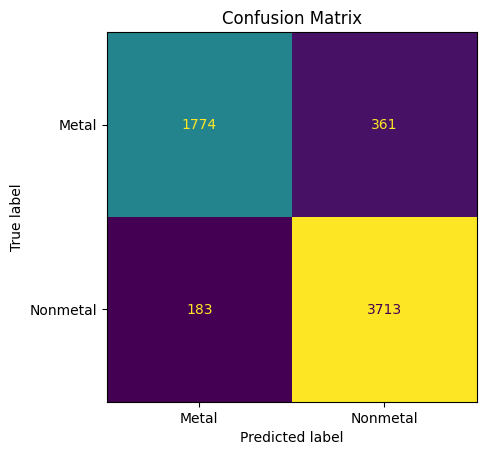

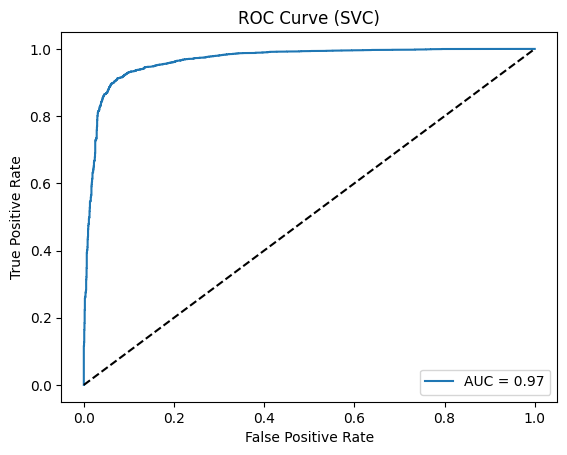

In [14]:
# plot Confusion Matrix
cm = confusion_matrix(y_class, y_cpred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Metal", "Nonmetal"])
disp.plot(colorbar = False)
plt.title('Confusion Matrix')
plt.savefig("cm.pdf", dpi=300)
plt.show()

# plot ROC curve
fpr, tpr, thresholds = roc_curve(y_class, y_cprob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_class, y_cprob):.2f}")
plt.plot([0, 1], [0, 1], 'k--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (SVC)")
plt.legend()
plt.savefig("rocauc.pdf", dpi=300)
plt.show()

- SVC model achieved a mean accuracy score of approximately 0.91 with a standard deviation of 0.011. (this means that the model is classifying reliably between metals and nonmetals)
- The ROC-AUC shows approximately 0.97. (this indicates the model demonstrates great classification performance and strong seperability between metals and nonmetals)
- The confusion matrix shows that the majority of predictions are correct. However, the model makes some mistakes by predicting metals as nonmetals than the other way around. (this means the model has a slight tendency to classify materials as nonmetals.)



### Fifth Step - SVR regressor
use SVR regressor to predict the band-gap value (Eg)

#### preprocessing data for SVR
we only want 'nonmetal' for this since if they are metal then the Eg = 0.

In [15]:
# for regressor
# we only want 'nonmetal' for predicting band gap
mask = df['Eg (eV)'] > 0
df_reg = df[mask]

X_reg = df_reg.drop(columns=['composition', 'Eg (eV)'])
y_reg = df_reg['Eg (eV)']


#### SVR model
we will use GridSearchCV to find the best parameters.
- set up for GridSearchCV
- find the best parameters
- using the best parameters, build a best SVR model
- report the scores(r2,mse) and plot predictions vs actual data

In [16]:
# GridSearchCV
param = {"svr__C": [1, 10, 100],
              "svr__epsilon": [0.01, 0.1, 0.5],
              "svr__gamma": [0.001, 0.01, 0.1]}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))])

grid = GridSearchCV(
    svr,
    param,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1)


# Find best parameters
grid.fit(X_reg, y_reg)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svr__C': [1, 10, ...], 'svr__epsilon': [0.01, 0.1, ...], 'svr__gamma': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time fo

In [17]:
# best parameters
best_params = grid.best_params_
print(best_params)

{'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 0.01}


In [18]:
# now using the best params, build a SVR model
best_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=best_params["svr__C"],
        epsilon=best_params["svr__epsilon"],
        gamma=best_params["svr__gamma"]))])

In [19]:
# accuracy scores
r2_scores = cross_val_score(
    best_svr,
    X_reg,
    y_reg,
    cv=cv,
    scoring="r2",
    n_jobs=-1)

# ROC-AUC scores
rmse_scores = cross_val_score(
    best_svr,
    X_reg,
    y_reg,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1)

print("R2 scores:", r2_scores)
print("Mean R2:", r2_scores.mean())
print("Std R2:", r2_scores.std())

print("RMSE scores:", - rmse_scores)
print("Mean RMSE:", - rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

R2 scores: [0.91706132 0.86740997 0.8978764  0.88132952 0.86780602]
Mean R2: 0.8862966457083946
Std R2: 0.01899388108323175
RMSE scores: [0.46036737 0.49941168 0.47083556 0.55665185 0.52027051]
Mean RMSE: 0.5015073945487243
Std RMSE: 0.03472929722163102


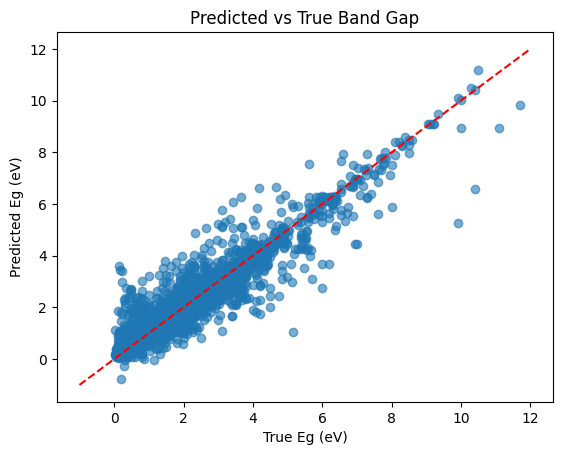

In [20]:
# plot pred vs true
y_pred = cross_val_predict(best_svr, X_reg,y_reg, cv=cv, n_jobs = -1)
plt.scatter(y_reg, y_pred, alpha=0.6)
plt.plot(np.linspace(-1,12),np.linspace(-1,12),'r--')
plt.xlabel("True Eg (eV)")
plt.ylabel("Predicted Eg (eV)")
plt.title("Predicted vs True Band Gap")
plt.savefig("predvstrue.pdf", dpi=300)
plt.show()

- The best SVR model achieved an RMSE of approximately 0.50 eV and an R squared value of 0.89. (This shows strong preidction performance)

- The predicted versus true band gap plot shows that most data points lie close to the diagonal, showing good agreement betwee predicted and experimental values. (This suggests the model effectively captures the relationship between cmoposition based features and bandgap)

- However, the model is less accurate for the materials with large band gaps.